# 2. Mean instead of median

**The mistake in one sentence:** the word average usually means the mean, and one huge value can move the mean far away from everybody.

Running on Google Colab? Run the next cell first. It downloads the repo so the data files are there. On your own computer you can skip it.

In [1]:
import os
from pathlib import Path
if not any((p / "src").exists() for p in [Path.cwd(), *Path.cwd().parents]):
    !git clone https://github.com/CS42org/data-make-sins.git
    os.chdir("data-make-sins/notebooks")

In [2]:
import sys
from pathlib import Path
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.append(str(root / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display
import dms

dms.style()

## The real case

The UBS Global Wealth Report 2023 lists two numbers for the United States. Wealth per adult: mean 551,347 dollars. Median 107,739 dollars. Most news stories quote the first number. The second one describes a real person, the one in the middle.

## A street of 20 people

In [3]:
pay = pd.Series([32, 36, 38, 41, 44, 46, 48, 50, 52, 53, 55, 56, 58, 60, 62, 64, 66, 70, 78, 88],
                name="yearly pay, thousand dollars")

before = pd.Series({"mean": pay.mean(), "median": pay.median()})
with_billionaire = pd.concat([pay, pd.Series([3000])], ignore_index=True)
after = pd.Series({"mean": with_billionaire.mean(), "median": with_billionaire.median()})

pd.DataFrame({"20 people": before, "plus one billionaire": after}).round(1)

,20 people,plus one billionaire
mean,54.8,195.1
median,54.0,55.0


The mean jumped by about 140,000. The median moved by 1,000. Nobody on the street earns anything near the new mean.

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.scatter(pay, np.zeros(len(pay)) + (np.arange(len(pay)) % 3) * 0.06, s=60, color=dms.GREY, zorder=3)
ax.scatter([230], [0.03], s=120, color=dms.RED, zorder=3)
ax.annotate("billionaire, 3,000 (off the chart)", (230, 0.03), (150, 0.32), color=dms.RED, arrowprops=dict(arrowstyle="->", color=dms.RED))
for value, label, color, y in [(before["mean"], "mean before", dms.RED, -0.12), (before["median"], "median before", dms.BLUE, -0.2),
                               (after["mean"], "mean after", dms.RED, -0.12), (after["median"], "median after", dms.BLUE, -0.2)]:
    ax.plot([value, value], [-0.02, 0.15], color=color, lw=2, alpha=0.9)
    ax.text(value, y, f"{label}\n{value:,.0f}", ha="center", fontsize=9, color=color)
ax.set_xlim(0, 240); ax.set_ylim(-0.3, 0.4); ax.set_yticks([])
ax.set_xlabel("yearly pay, thousand dollars")
ax.set_title("One billionaire moves the mean, not the median")
dms.save(fig, "02_mean_vs_median.png")
plt.show()

## Animated figure

Watch the mean slide away as the newcomer's pay grows. The median hardly moves.

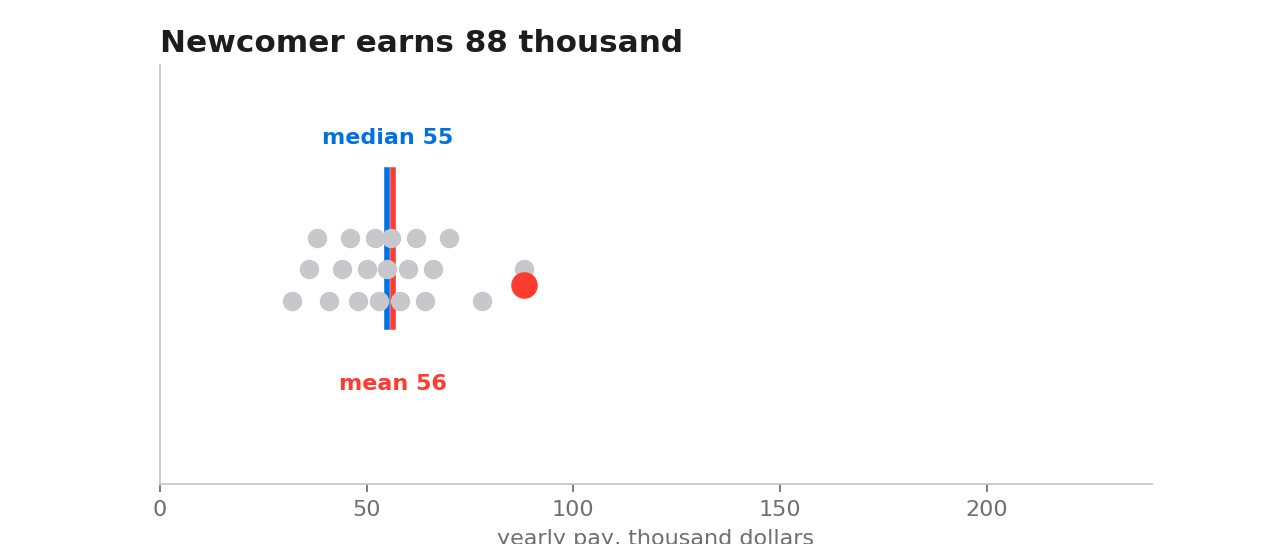

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.set_xlim(0, 240); ax.set_ylim(-0.35, 0.45); ax.set_yticks([])
ax.set_xlabel("yearly pay, thousand dollars")
ax.scatter(pay, (np.arange(len(pay)) % 3) * 0.06, s=60, color=dms.GREY, zorder=3)
newcomer = ax.scatter([], [], s=120, color=dms.RED, zorder=4)
mean_line, = ax.plot([], [], color=dms.RED, lw=2.5)
median_line, = ax.plot([], [], color=dms.BLUE, lw=2.5)
mean_text = ax.text(0, -0.15, "", ha="center", color=dms.RED, fontsize=10, weight="bold")
median_text = ax.text(0, 0.32, "", ha="center", color=dms.BLUE, fontsize=10, weight="bold")
title = ax.set_title("")

newcomer_pay = np.concatenate([np.full(10, 88), np.geomspace(88, 3000, 50), np.full(15, 3000)])

def update(i):
    v = newcomer_pay[i]
    everyone = pd.concat([pay, pd.Series([v])], ignore_index=True)
    m, md = everyone.mean(), everyone.median()
    newcomer.set_offsets([[min(v, 232), 0.03]])
    mean_line.set_data([m, m], [-0.05, 0.25]); median_line.set_data([md, md], [-0.05, 0.25])
    mean_text.set_position((m, -0.17)); mean_text.set_text(f"mean {m:,.0f}")
    median_text.set_position((md, 0.3)); median_text.set_text(f"median {md:,.0f}")
    title.set_text(f"Newcomer earns {v:,.0f} thousand" + ("  (off the chart)" if v > 232 else ""))
    return newcomer, mean_line, median_line, mean_text, median_text, title

anim = FuncAnimation(fig, update, frames=len(newcomer_pay), interval=100)
gif = dms.FIG / "02_mean_slides.gif"
anim.save(gif, writer=PillowWriter(fps=10))
plt.close(fig)
display(Image(filename=str(gif)))

## Real numbers: wealth per adult, 2023

In [6]:
wealth = pd.read_csv(dms.DATA / "wealth_per_adult_2023.csv", index_col="country")
wealth["mean divided by median"] = (wealth.mean_usd / wealth.median_usd).round(1)
wealth

,mean_usd,median_usd,mean divided by median
country,,,
Switzerland,685226,167353,4.1
United States,551347,107739,5.1
Australia,496819,247453,2.0
Denmark,409000,186041,2.2


In [7]:
fig, ax = plt.subplots()
x = np.arange(len(wealth))
ax.bar(x - 0.2, wealth.mean_usd / 1000, width=0.4, color=dms.RED, label="mean (what the news says)")
ax.bar(x + 0.2, wealth.median_usd / 1000, width=0.4, color=dms.BLUE, label="median (the person in the middle)")
ax.set_xticks(x, wealth.index); ax.set_ylabel("thousand dollars per adult")
ax.set_title("Wealth per adult, UBS Global Wealth Report 2023")
ax.legend()
dms.save(fig, "02_wealth_mean_median.png")
plt.show()

## Better method

When some values are huge, report the median. Add the range from the 25th to the 75th person so readers see the spread. `describe()` gives you all of it in one line.

In [8]:
with_billionaire.describe().round(1)

count      21.0
mean      195.1
std       642.8
min        32.0
25%        46.0
50%        55.0
75%        64.0
max      3000.0
dtype: float64

In [9]:
from scipy.stats import trim_mean
print("mean            ", round(with_billionaire.mean(), 1))
print("median          ", with_billionaire.median())
print("trimmed mean 10%", round(trim_mean(with_billionaire, 0.1), 1))
print("25th to 75th    ", with_billionaire.quantile(0.25), "to", with_billionaire.quantile(0.75))

mean             195.1
median           55.0
trimmed mean 10% 55.4
25th to 75th     46.0 to 64.0


## Ask this

Is this the mean or the median?